# Workout Class Classifier - Random Forest

This notebook trains a Random Forest classifier to predict workout classes from pose sequences.

The model:
- Takes sequences of shape (15, 33, 3) - 15 frames, 33 landmarks, 3 coordinates
- Flattens them to feature vectors
- Predicts workout classes with one-hot encoded output

In [25]:
import numpy as np
import pandas as pd
import json
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

## Load Training Data

In [26]:
# Load training data from .npz file
data_path = Path('../../Data/output/training_data.npz')
metadata_path = Path('../../Data/output/training_data_metadata.json')

# Load metadata
with open(metadata_path, 'r') as f:
    metadata = json.load(f)

print("Dataset Metadata:")
print(f"  Number of samples: {metadata['n_samples']}")
print(f"  Number of classes: {metadata['n_classes']}")
print(f"  Sequence length: {metadata['sequence_length']}")
print(f"  Number of landmarks: {metadata['n_landmarks']}")
print(f"  Number of coordinates: {metadata['n_coords']}")
print(f"  Feature shape: {metadata['feature_shape']}")
print(f"\nClass names: {metadata['class_names']}")
print(f"\nClass distribution:")
for cls, count in metadata['class_distribution'].items():
    print(f"  {cls}: {count}")

# Load the .npz file
data = np.load(data_path, allow_pickle=True)

# Check available keys
print(f"\nAvailable keys in .npz file: {list(data.keys())}")

# Load data - note: the key is 'y' not 'y_encoded' based on how it was saved
X = data['X']  # Shape: (n_samples, 15, 33, 3)
y_onehot = data['y_onehot']  # One-hot encoded labels
y_encoded = data['y']  # Encoded labels (integers) - key is 'y' not 'y_encoded'
y_raw = data['y_raw']  # Raw class names
class_names = data['class_names']  # Class names array

print(f"\nLoaded data shapes:")
print(f"  X shape: {X.shape}")
print(f"  y_onehot shape: {y_onehot.shape}")
print(f"  y_encoded shape: {y_encoded.shape}")
print(f"  Number of classes: {len(class_names)}")

Dataset Metadata:
  Number of samples: 55196
  Number of classes: 16
  Sequence length: 15
  Number of landmarks: 12
  Number of coordinates: 3
  Feature shape: [15, 12, 3]

Class names: ['barbell biceps curl', 'bench press', 'chest fly machine', 'deadlift', 'incline bench press', 'lat pulldown', 'lateral raise', 'leg extension', 'leg raises', 'push-up', 'russian twist', 'shoulder press', 'squat', 't bar row', 'tricep Pushdown', 'tricep dips']

Class distribution:
  barbell biceps curl: 2864
  bench press: 1510
  chest fly machine: 2946
  deadlift: 2626
  incline bench press: 4176
  lat pulldown: 3512
  lateral raise: 3652
  leg extension: 3398
  leg raises: 3248
  push-up: 3706
  russian twist: 3330
  shoulder press: 3096
  squat: 5100
  t bar row: 4346
  tricep Pushdown: 3234
  tricep dips: 4452

Available keys in .npz file: ['X', 'y', 'y_onehot', 'y_raw', 'class_names']

Loaded data shapes:
  X shape: (55196, 15, 12, 3)
  y_onehot shape: (55196, 16)
  y_encoded shape: (55196,)
  Num

## Preprocess Data

Flatten the sequences from (15, 33, 3) to a 1D feature vector for the Random Forest model.

In [27]:
# Flatten sequences: (n_samples, 15, 33, 3) -> (n_samples, 15*33*3)
X_flat = X.reshape(X.shape[0], -1)
print(f"Flattened X shape: {X_flat.shape}")
print(f"Number of features per sample: {X_flat.shape[1]}")

# Check for NaN or infinite values
print(f"\nData quality check:")
print(f"  NaN values in X: {np.isnan(X_flat).sum()}")
print(f"  Infinite values in X: {np.isinf(X_flat).sum()}")

# Replace any NaN or infinite values with 0
X_flat = np.nan_to_num(X_flat, nan=0.0, posinf=0.0, neginf=0.0)

Flattened X shape: (55196, 540)
Number of features per sample: 540

Data quality check:
  NaN values in X: 0
  Infinite values in X: 0


## Split Data into Train and Test Sets

In [28]:
# Split data into train and test sets
# Using y_encoded for splitting (integer labels)
X_train, X_test, y_train_encoded, y_test_encoded, y_train_onehot, y_test_onehot = train_test_split(
    X_flat, y_encoded, y_onehot,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded  # Ensure balanced split across classes
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Feature dimension: {X_train.shape[1]}")
print(f"Number of classes: {y_train_onehot.shape[1]}")

Training set size: 44156
Test set size: 11040
Feature dimension: 540
Number of classes: 16


## Train Random Forest Classifier

Random Forest is an ensemble method that builds multiple decision trees and combines their predictions.

In [ ]:
# Initialize Random Forest classifier for multi-class classification
model = RandomForestClassifier(
    n_estimators=200,        # Number of trees in the forest
    max_depth=20,            # Maximum depth of the tree
    min_samples_split=5,     # Minimum number of samples required to split a node
    min_samples_leaf=2,      # Minimum number of samples required at a leaf node
    max_features='sqrt',     # Number of features to consider for best split
    random_state=42,
    n_jobs=-1,               # Use all available cores
    class_weight='balanced',  # Automatically adjust weights inversely proportional to class frequencies
    verbose=1                # Print progress
)

print("Training Random Forest classifier...")
# Train on encoded labels (integers)
model.fit(X_train, y_train_encoded)

print("\nTraining completed!")

Training Random Forest classifier...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:   13.0s



Training completed!


[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:   14.5s finished


## Evaluate Model

Make predictions and evaluate the model performance.

In [30]:
# Make predictions
# predict_proba returns probabilities for each class (one-hot like format)
y_pred_proba = model.predict_proba(X_test)  # Shape: (n_test_samples, n_classes)
y_pred_encoded = model.predict(X_test)     # Predicted class indices

# Convert predictions to one-hot encoded format
y_pred_onehot = np.zeros_like(y_test_onehot)
y_pred_onehot[np.arange(len(y_pred_encoded)), y_pred_encoded] = 1

print("Predictions shape:")
print(f"  y_pred_proba shape: {y_pred_proba.shape}")
print(f"  y_pred_onehot shape: {y_pred_onehot.shape}")
print(f"  y_test_onehot shape: {y_test_onehot.shape}")

# Calculate accuracy
accuracy = accuracy_score(y_test_encoded, y_pred_encoded)
print(f"\nTest Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

Predictions shape:
  y_pred_proba shape: (11040, 16)
  y_pred_onehot shape: (11040, 16)
  y_test_onehot shape: (11040, 16)

Test Accuracy: 0.9361 (93.61%)


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    0.1s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    0.0s finished


In [31]:
# Detailed classification report
print("\nClassification Report:")
print(classification_report(
    y_test_encoded, 
    y_pred_encoded, 
    target_names=class_names,
    digits=3
))


Classification Report:
                     precision    recall  f1-score   support

barbell biceps curl      0.945     0.937     0.941       573
        bench press      0.554     0.957     0.701       302
  chest fly machine      0.995     0.969     0.982       589
           deadlift      0.830     0.983     0.900       525
incline bench press      0.979     0.914     0.945       835
       lat pulldown      0.961     0.889     0.924       702
      lateral raise      0.977     0.934     0.955       731
      leg extension      0.974     0.894     0.933       680
         leg raises      0.928     0.978     0.953       650
            push-up      0.997     0.996     0.997       741
      russian twist      0.974     0.943     0.958       666
     shoulder press      0.935     0.992     0.962       619
              squat      0.977     0.914     0.944      1020
          t bar row      0.949     0.899     0.923       869
    tricep Pushdown      0.952     0.893     0.922       647

## Confusion Matrix

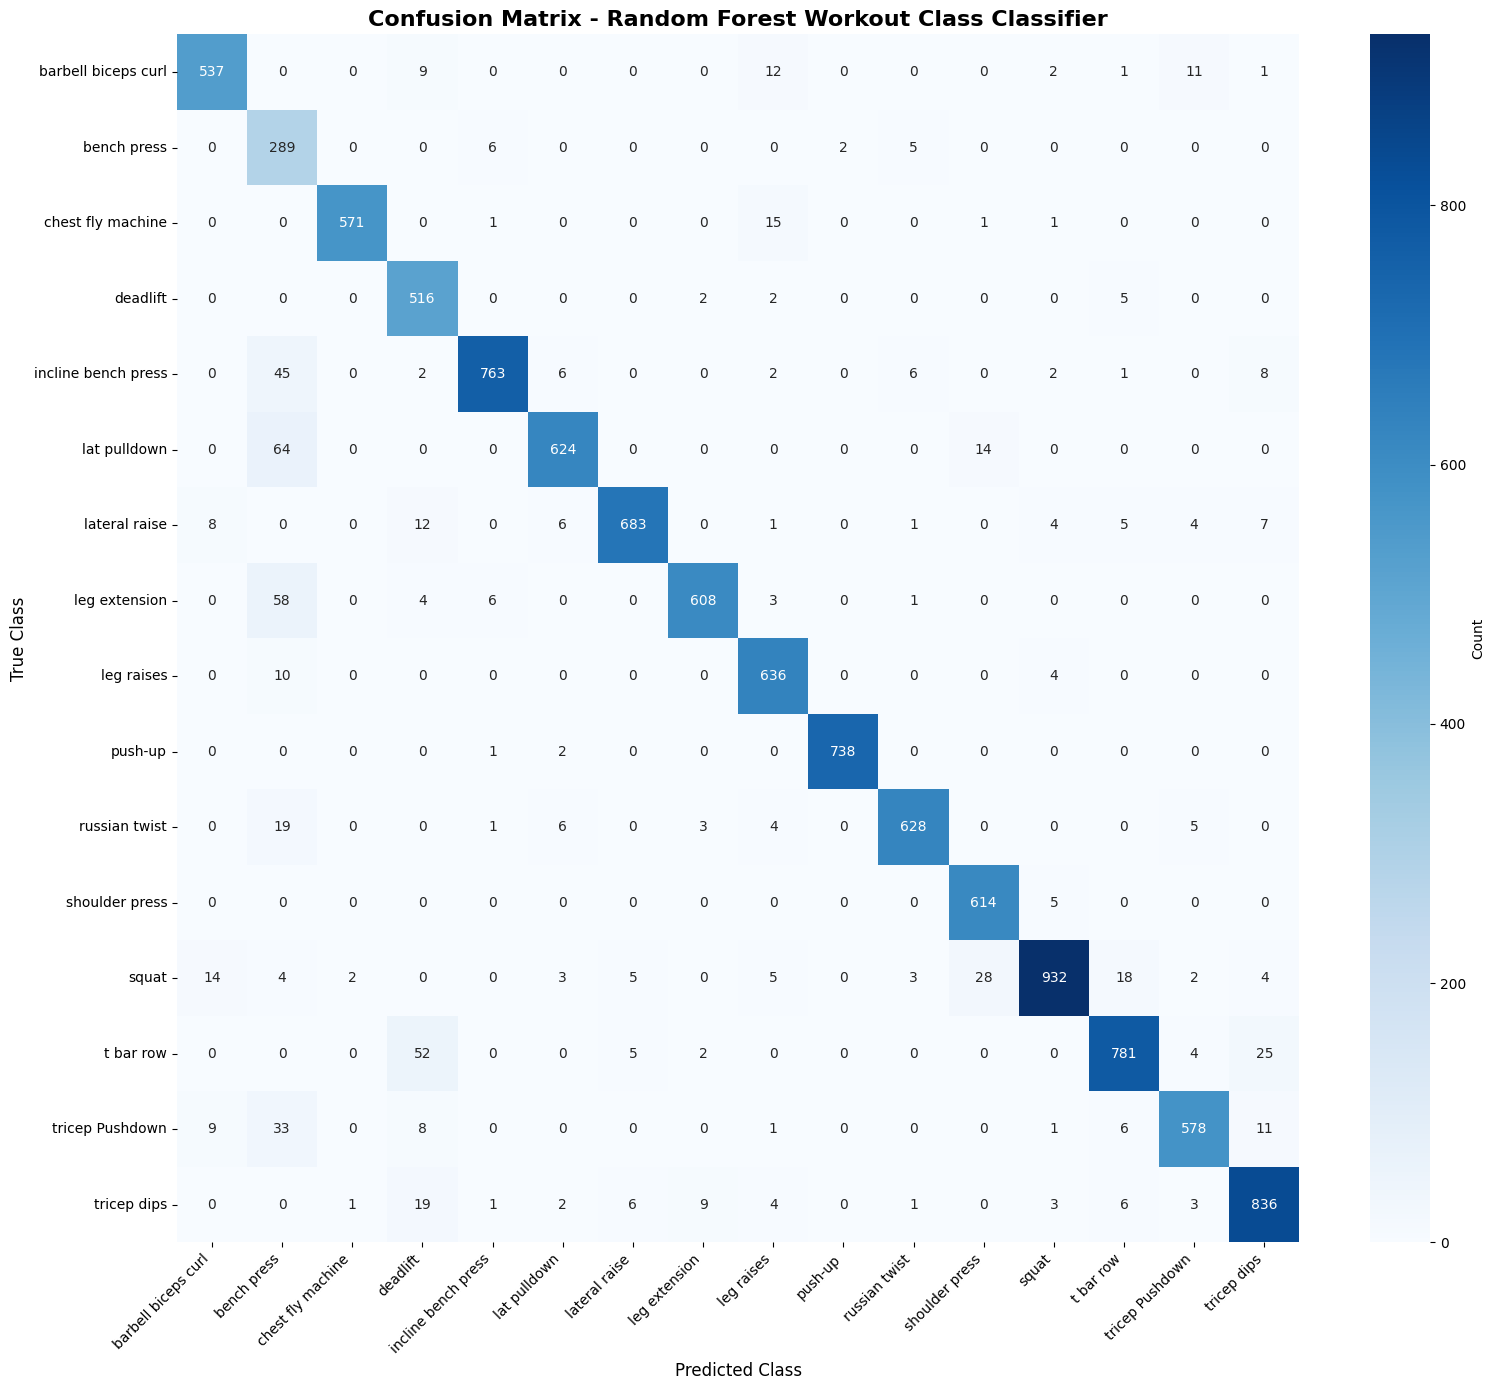


Per-Class Accuracy:
  barbell biceps curl: 0.9372 (93.72%)
  bench press: 0.9570 (95.70%)
  chest fly machine: 0.9694 (96.94%)
  deadlift: 0.9829 (98.29%)
  incline bench press: 0.9138 (91.38%)
  lat pulldown: 0.8889 (88.89%)
  lateral raise: 0.9343 (93.43%)
  leg extension: 0.8941 (89.41%)
  leg raises: 0.9785 (97.85%)
  push-up: 0.9960 (99.60%)
  russian twist: 0.9429 (94.29%)
  shoulder press: 0.9919 (99.19%)
  squat: 0.9137 (91.37%)
  t bar row: 0.8987 (89.87%)
  tricep Pushdown: 0.8934 (89.34%)
  tricep dips: 0.9383 (93.83%)


In [32]:
# Create confusion matrix
cm = confusion_matrix(y_test_encoded, y_pred_encoded)

# Plot confusion matrix
plt.figure(figsize=(16, 14))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={'label': 'Count'}
)
plt.title('Confusion Matrix - Random Forest Workout Class Classifier', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('True Class', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Calculate per-class accuracy
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)
print("\nPer-Class Accuracy:")
for i, cls_name in enumerate(class_names):
    print(f"  {cls_name}: {per_class_accuracy[i]:.4f} ({per_class_accuracy[i]*100:.2f}%)")

## Feature Importance

Visualize which features (landmarks/coordinates) are most important for classification.

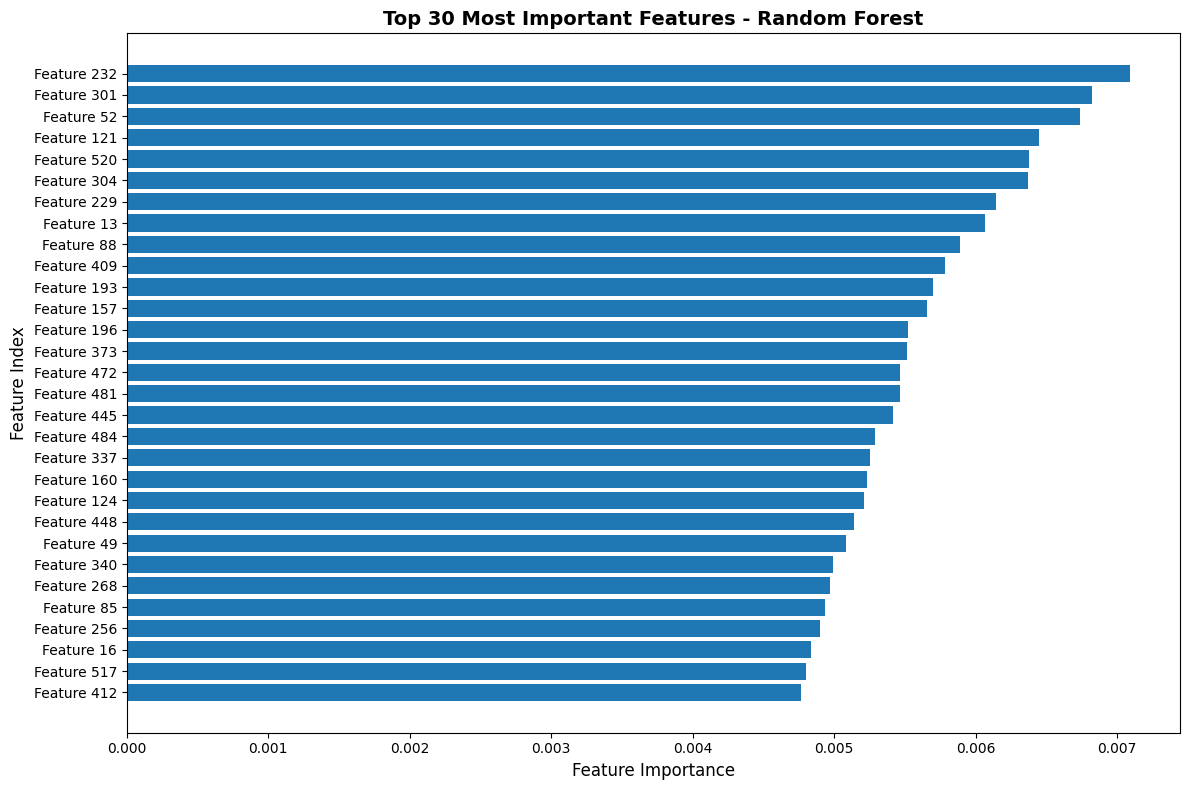


Top 30 most important features:
  Feature 232: Importance=0.007090 (Frame 2, Landmark 11, y)
  Feature 301: Importance=0.006820 (Frame 3, Landmark 1, y)
  Feature 52: Importance=0.006738 (Frame 0, Landmark 17, y)
  Feature 121: Importance=0.006451 (Frame 1, Landmark 7, y)
  Feature 520: Importance=0.006379 (Frame 5, Landmark 8, y)
  Feature 304: Importance=0.006371 (Frame 3, Landmark 2, y)
  Feature 229: Importance=0.006143 (Frame 2, Landmark 10, y)
  Feature 13: Importance=0.006063 (Frame 0, Landmark 4, y)
  Feature 88: Importance=0.005891 (Frame 0, Landmark 29, y)
  Feature 409: Importance=0.005783 (Frame 4, Landmark 4, y)


In [33]:
# Get feature importance
feature_importance = model.feature_importances_

# Get top 30 most important features
top_n = 30
top_indices = np.argsort(feature_importance)[-top_n:][::-1]
top_importance = feature_importance[top_indices]

# Plot feature importance
plt.figure(figsize=(12, 8))
plt.barh(range(len(top_importance)), top_importance)
plt.yticks(range(len(top_importance)), [f'Feature {i}' for i in top_indices])
plt.xlabel('Feature Importance', fontsize=12)
plt.ylabel('Feature Index', fontsize=12)
plt.title(f'Top {top_n} Most Important Features - Random Forest', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\nTop {top_n} most important features:")
for idx, imp in zip(top_indices[:10], top_importance[:10]):
    # Calculate which frame, landmark, and coordinate this feature represents
    frame_idx = idx // (33 * 3)
    remainder = idx % (33 * 3)
    landmark_idx = remainder // 3
    coord_idx = remainder % 3
    coord_name = ['x', 'y', 'z'][coord_idx]
    print(f"  Feature {idx}: Importance={imp:.6f} (Frame {frame_idx}, Landmark {landmark_idx}, {coord_name})")

## Example Predictions

Show some example predictions with probabilities.

In [34]:
# Show some example predictions
n_examples = 10
example_indices = np.random.choice(len(X_test), n_examples, replace=False)

print("Example Predictions:")
print("=" * 80)
for idx in example_indices:
    true_class_idx = y_test_encoded[idx]
    pred_class_idx = y_pred_encoded[idx]
    true_class = class_names[true_class_idx]
    pred_class = class_names[pred_class_idx]
    probabilities = y_pred_proba[idx]
    
    # Get top 3 predicted classes
    top3_indices = np.argsort(probabilities)[-3:][::-1]
    
    print(f"\nSample {idx}:")
    print(f"  True class: {true_class}")
    print(f"  Predicted class: {pred_class} {'✓' if true_class == pred_class else '✗'}")
    print(f"  Top 3 predictions:")
    for i, class_idx in enumerate(top3_indices):
        print(f"    {i+1}. {class_names[class_idx]}: {probabilities[class_idx]:.4f}")
    
    # Show one-hot encoded output
    print(f"  One-hot encoded prediction (first 5 classes): {y_pred_onehot[idx][:5]}")
    print(f"  One-hot encoded true label (first 5 classes): {y_test_onehot[idx][:5]}")

Example Predictions:

Sample 9733:
  True class: shoulder press
  Predicted class: shoulder press ✓
  Top 3 predictions:
    1. shoulder press: 0.5124
    2. lat pulldown: 0.1859
    3. leg raises: 0.0800
  One-hot encoded prediction (first 5 classes): [0. 0. 0. 0. 0.]
  One-hot encoded true label (first 5 classes): [0. 0. 0. 0. 0.]

Sample 11000:
  True class: russian twist
  Predicted class: russian twist ✓
  Top 3 predictions:
    1. russian twist: 0.4715
    2. leg extension: 0.2444
    3. leg raises: 0.1441
  One-hot encoded prediction (first 5 classes): [0. 0. 0. 0. 0.]
  One-hot encoded true label (first 5 classes): [0. 0. 0. 0. 0.]

Sample 2447:
  True class: lat pulldown
  Predicted class: lat pulldown ✓
  Top 3 predictions:
    1. lat pulldown: 0.4682
    2. shoulder press: 0.1215
    3. incline bench press: 0.0918
  One-hot encoded prediction (first 5 classes): [0. 0. 0. 0. 0.]
  One-hot encoded true label (first 5 classes): [0. 0. 0. 0. 0.]

Sample 8206:
  True class: shoul

## Save Model

Save the trained model for future use.

In [35]:
import pickle
from pathlib import Path

# Create output directory if it doesn't exist
output_dir = Path('models')
output_dir.mkdir(exist_ok=True)

# Save the model
model_path = output_dir / 'randomforest_workout_classifier.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(model, f)

# Save class names for reference
class_names_path = output_dir / 'class_names_rf.json'
with open(class_names_path, 'w') as f:
    json.dump(class_names.tolist(), f, indent=2)

# Save metadata about the model
model_metadata = {
    'model_type': 'RandomForest',
    'n_classes': len(class_names),
    'n_features': X_flat.shape[1],
    'feature_shape': metadata['feature_shape'],
    'class_names': class_names.tolist(),
    'test_accuracy': float(accuracy),
    'model_path': str(model_path),
    'class_names_path': str(class_names_path),
    'n_estimators': 200,
    'max_depth': 20,
    'min_samples_split': 5,
    'min_samples_leaf': 2
}

metadata_path = output_dir / 'model_metadata_rf.json'
with open(metadata_path, 'w') as f:
    json.dump(model_metadata, f, indent=2)

print(f"Model saved to: {model_path}")
print(f"Class names saved to: {class_names_path}")
print(f"Model metadata saved to: {metadata_path}")

Model saved to: models/randomforest_workout_classifier.pkl
Class names saved to: models/class_names_rf.json
Model metadata saved to: models/model_metadata_rf.json


## Prediction Function

Helper function to make predictions on new sequences with one-hot encoded output.

In [36]:
def predict_workout_class(sequence, model, class_names, return_onehot=True):
    """
    Predict workout class for a sequence using Random Forest.
    
    Args:
        sequence: numpy array of shape (15, 33, 3) or (1, 15, 33, 3)
        model: Trained Random Forest model
        class_names: Array of class names
        return_onehot: If True, return one-hot encoded prediction, else return class name
    
    Returns:
        If return_onehot=True: one-hot encoded array of shape (n_classes,)
        If return_onehot=False: predicted class name (string)
    """
    # Ensure sequence is the right shape
    if sequence.ndim == 3:
        sequence = sequence.reshape(1, -1)  # Flatten to (1, 15*33*3)
    elif sequence.ndim == 4:
        sequence = sequence.reshape(sequence.shape[0], -1)  # Flatten to (n, 15*33*3)
    else:
        sequence = sequence.reshape(1, -1)  # Flatten to (1, n_features)
    
    # Handle NaN and infinite values
    sequence = np.nan_to_num(sequence, nan=0.0, posinf=0.0, neginf=0.0)
    
    # Get probabilities
    probabilities = model.predict_proba(sequence)
    
    if return_onehot:
        # Convert to one-hot encoded format
        pred_class_idx = np.argmax(probabilities, axis=1)
        onehot = np.zeros((len(pred_class_idx), len(class_names)))
        onehot[np.arange(len(pred_class_idx)), pred_class_idx] = 1
        return onehot[0] if onehot.shape[0] == 1 else onehot
    else:
        # Return class name
        pred_class_idx = np.argmax(probabilities, axis=1)
        if len(pred_class_idx) == 1:
            return class_names[pred_class_idx[0]]
        else:
            return [class_names[idx] for idx in pred_class_idx]

# Test the prediction function
print("Testing prediction function:")
test_sequence = X_test[0:1].reshape(1, 15, 12, 3)  # Reshape back to original format
pred_onehot = predict_workout_class(test_sequence, model, class_names, return_onehot=True)
pred_class = predict_workout_class(test_sequence, model, class_names, return_onehot=False)

print(f"  Input shape: {test_sequence.shape}")
print(f"  Predicted class: {pred_class}")
print(f"  One-hot encoded output shape: {pred_onehot.shape}")
print(f"  One-hot encoded output: {pred_onehot}")
print(f"  True class: {class_names[y_test_encoded[0]]}")

Testing prediction function:
  Input shape: (1, 15, 12, 3)
  Predicted class: squat
  One-hot encoded output shape: (16,)
  One-hot encoded output: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
  True class: squat


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    0.0s finished
